In [ ]:
!pip install segmentation-models-pytorch


In [4]:
import os
import time
from glob import glob
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import albumentations as A
from scipy.ndimage.morphology import binary_dilation
import segmentation_models_pytorch as smp
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

<ipython-input-4-0767f6e6a1ca>:12: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_dilation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient                    110 non-null    object 
 1   RNASeqCluster              92 non-null     float64
 2   MethylationCluster         109 non-null    float64
 3   miRNACluster               110 non-null    int64  
 4   CNCluster                  108 non-null    float64
 5   RPPACluster                98 non-null     float64
 6   OncosignCluster            105 non-null    float64
 7   COCCluster                 110 non-null    int64  
 8   histological_type          109 non-null    float64
 9   neoplasm_histologic_grade  109 non-null    float64
 10  tumor_tissue_site          109 non-null    float64
 11  laterality                 109 non-null    float64
 12  tumor_location             109 non-null    float64
 13  gender                     109 non-null    float64

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b7-dcc49843.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b7-dcc49843.pth
100%|██████████| 254M/254M [00:02<00:00, 119MB/s]


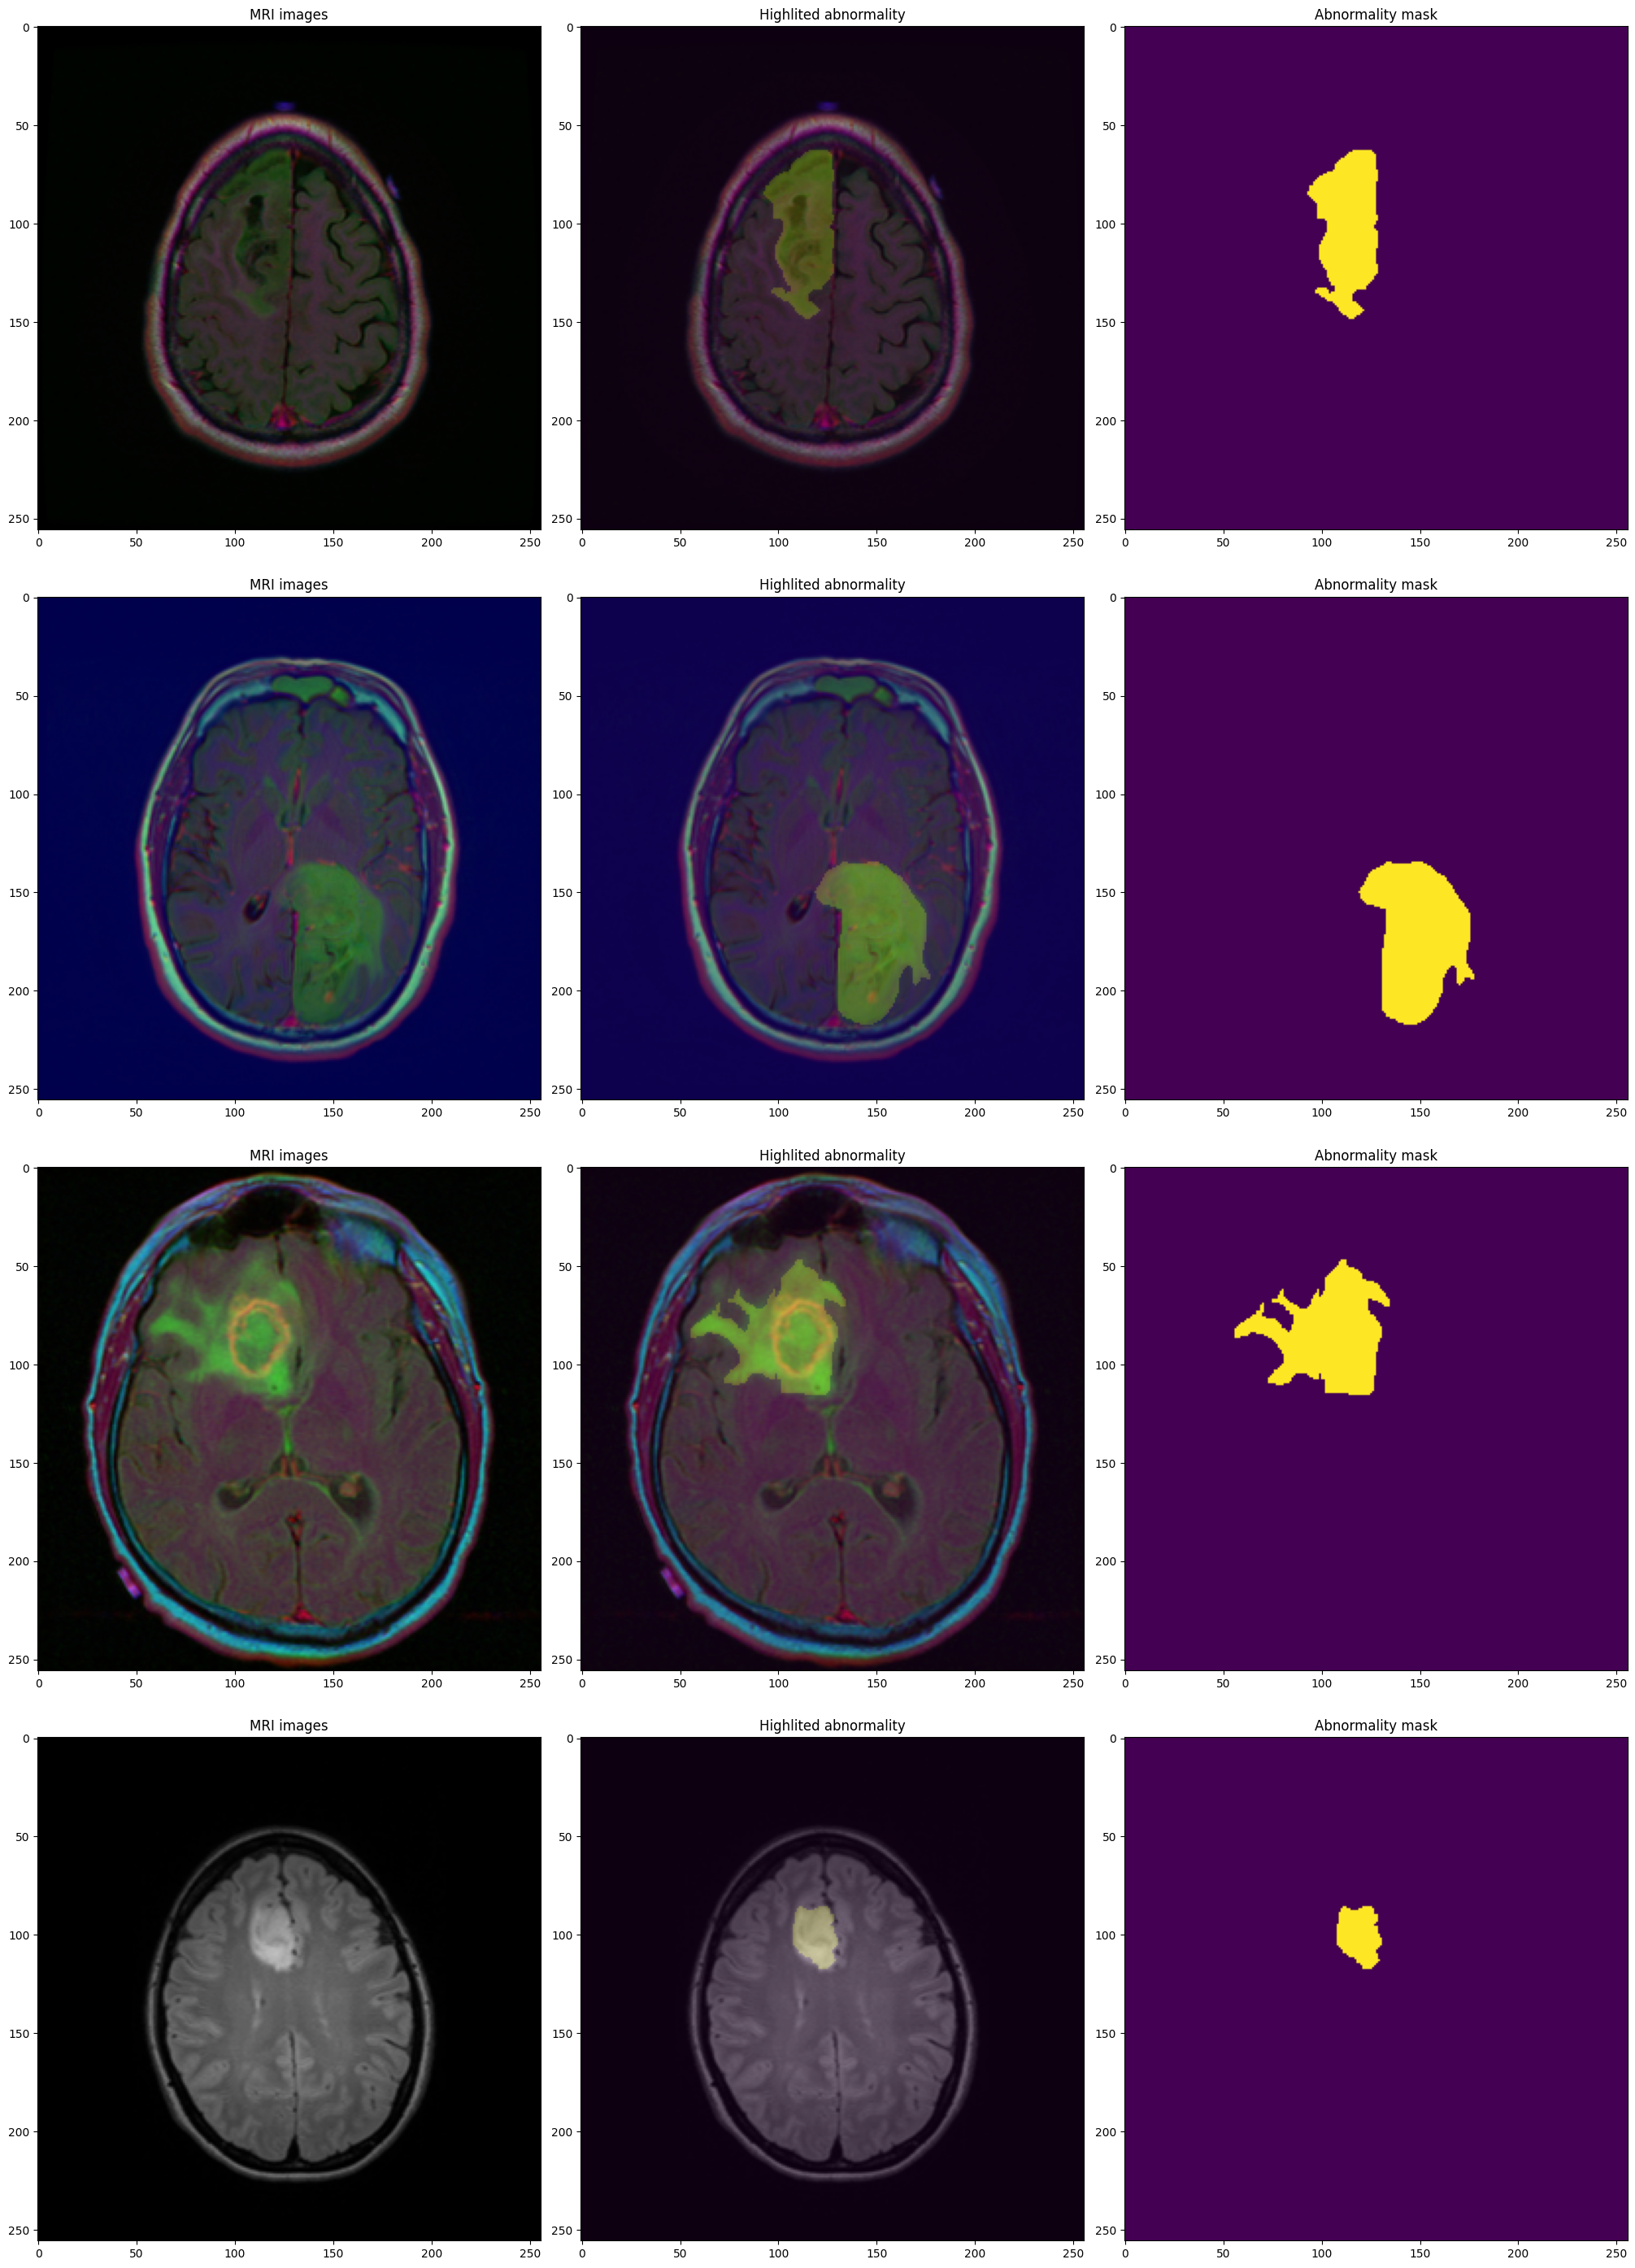

In [5]:




#Data Loading

files_dir = r"/content/drive/MyDrive/Unet_Data_Set/Brain MRI Segmentation/lgg-mri-segmentation/kaggle_3m"
file_paths = glob(f'{files_dir}/*/*[0-9].tif')


csv_path = r"/content/drive/MyDrive/Unet_Data_Set/Brain MRI Segmentation/lgg-mri-segmentation/kaggle_3m/data.csv"
df = pd.read_csv(csv_path)

df.info()

imputer = SimpleImputer(strategy="most_frequent")

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df


def get_file_row(path):
    """Produces ID of a patient, image and mask filenames from a particular path"""
    path_no_ext, ext = os.path.splitext(path)
    filename = os.path.basename(path)

    patient_id = '_'.join(filename.split('_')[:3]) # Patient ID in the csv file consists of 3 first filename segments

    return [patient_id, path, f'{path_no_ext}_mask{ext}']


filenames_df = pd.DataFrame((get_file_row(filename) for filename in file_paths), columns=['Patient', 'image_filename', 'mask_filename'])
filenames_df


class MriDataset(Dataset):
    def __init__(self, df, transform=None, mean=0.5, std=0.25):
        super(MriDataset, self).__init__()
        self.df = df
        self.transform = transform
        self.mean = mean
        self.std = std


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx, raw=False):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_filename'], cv2.IMREAD_UNCHANGED)
        mask = cv2.imread(row['mask_filename'], cv2.IMREAD_GRAYSCALE)
        if raw:
            return img, mask

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        img = T.functional.to_tensor(img)
        mask = mask // 255
        mask = torch.Tensor(mask)
        return img, mask

df = pd.merge(df, filenames_df, on="Patient")

train_df, test_df = train_test_split(df, test_size=0.3)
test_df, valid_df = train_test_split(test_df, test_size=0.5)

####
transform = A.Compose([
    A.ChannelDropout(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.ColorJitter(p=0.3),
])

train_dataset = MriDataset(train_df, transform)
valid_dataset = MriDataset(valid_df)
test_dataset = MriDataset(test_df)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)


%matplotlib inline
n_examples = 4

fig, axs = plt.subplots(n_examples, 3, figsize=(20, n_examples*7), constrained_layout=True)
i = 0
for ax in axs:
    while True:
        image, mask = train_dataset.__getitem__(i, raw=True)
        i += 1
        if np.any(mask):
            ax[0].set_title("MRI images")
            ax[0].imshow(image)
            ax[1].set_title("Highlited abnormality")
            ax[1].imshow(image)
            ax[1].imshow(mask, alpha=0.2)
            ax[2].imshow(mask)
            ax[2].set_title("Abnormality mask")
            break


#Trainning
class EarlyStopping():
    """
    Stops training when loss stops decreasing in a PyTorch module.
    """
    def __init__(self, patience:int = 6, min_delta: float = 0, weights_path: str = 'weights.pt'):
        """
        :param patience: number of epochs of non-decreasing loss before stopping
        :param min_delta: minimum difference between best and new loss that is considered
            an improvement
        :paran weights_path: Path to the file that should store the model's weights
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.weights_path = weights_path

    def __call__(self, val_loss: float, model: torch.nn.Module):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.weights_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_weights(self, model: torch.nn.Module):
        """
        Loads weights of the best model.
        :param model: model to which the weigths should be loaded
        """
        return model.load_state_dict(torch.load(self.weights_path))
def iou_pytorch(predictions: torch.Tensor, labels: torch.Tensor, e: float = 1e-7):
    """Calculates Intersection over Union for a tensor of predictions"""
    predictions = torch.where(predictions > 0.5, 1, 0)
    labels = labels.byte()

    intersection = (predictions & labels).float().sum((1, 2))
    union = (predictions | labels).float().sum((1, 2))

    iou = (intersection + e) / (union + e)
    return iou

def dice_pytorch(predictions: torch.Tensor, labels: torch.Tensor, e: float = 1e-7):
    """Calculates Dice coefficient for a tensor of predictions"""
    predictions = torch.where(predictions > 0.5, 1, 0)
    labels = labels.byte()

    intersection = (predictions & labels).float().sum((1, 2))
    return ((2 * intersection) + e) / (predictions.float().sum((1, 2)) + labels.float().sum((1, 2)) + e)

def BCE_dice(output, target, alpha=0.01):
    bce = torch.nn.functional.binary_cross_entropy(output, target)
    soft_dice = 1 - dice_pytorch(output, target).mean()
    return bce + alpha * soft_dice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)


# Move the model to the selected device
model.to(device)

def training_loop(epochs, model, train_loader, valid_loader, optimizer, loss_fn, lr_scheduler):
    history = {'train_loss': [], 'val_loss': [], 'val_IoU': [], 'val_dice': []}
    early_stopping = EarlyStopping(patience=7)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        running_loss = 0
        model.train()
        for i, data in enumerate(tqdm(train_loader)):
            img, mask = data
            img, mask = img.to(device), mask.to(device)
            predictions = model(img)
            predictions = predictions.squeeze(1)
            loss = loss_fn(predictions, mask)
            running_loss += loss.item() * img.size(0)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        model.eval()
        with torch.no_grad():
            running_IoU = 0
            running_dice = 0
            running_valid_loss = 0
            for i, data in enumerate(valid_loader):
                img, mask = data
                img, mask = img.to(device), mask.to(device)
                predictions = model(img)
                predictions = predictions.squeeze(1)
                running_dice += dice_pytorch(predictions, mask).sum().item()
                running_IoU += iou_pytorch(predictions, mask).sum().item()
                loss = loss_fn(predictions, mask)
                running_valid_loss += loss.item() * img.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        val_loss = running_valid_loss / len(valid_loader.dataset)
        val_dice = running_dice / len(valid_loader.dataset)
        val_IoU = running_IoU / len(valid_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_IoU'].append(val_IoU)
        history['val_dice'].append(val_dice)
        print(f'Epoch: {epoch}/{epochs} | Training loss: {train_loss} | Validation loss: {val_loss} | Validation Mean IoU: {val_IoU} '
         f'| Validation Dice coefficient: {val_dice}')

        lr_scheduler.step(val_loss)
        if early_stopping(val_loss, model):
            early_stopping.load_weights(model)
            break
    model.eval()
    return history



In [6]:
loss_fn = BCE_dice
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 1
lr_scheduler = ReduceLROnPlateau(optimizer=optimizer, patience=2,factor=0.2)

history = training_loop(epochs, model, train_loader, valid_loader, optimizer, loss_fn, lr_scheduler)

100%|██████████| 172/172 [40:34<00:00, 14.15s/it]


Epoch: 1/1 | Training loss: 0.0677209004109556 | Validation loss: 0.12393800287933673 | Validation Mean IoU: 0.6499014814021223 | Validation Dice coefficient: 0.6875632819482835


### Classification Model Updated One

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
import time

# Define the Hybrid Convolutional Layer
class HybridConvLayer(Layer):
    def __init__(self, filters, kernel_size1, kernel_size2, **kwargs):
        super(HybridConvLayer, self).__init__(**kwargs)
        self.conv1 = Conv2D(filters, kernel_size1, padding='same', activation='relu')
        self.conv2 = Conv2D(filters, kernel_size2, padding='same', activation='relu')

    def call(self, inputs):
        x1 = self.conv1(inputs)
        x2 = self.conv2(inputs)
        return tf.keras.layers.Concatenate()([x1, x2])


start_time = time.time()

tumor_folders = [
    "/content/drive/MyDrive/Classsification_Data_Set/Brain_MRI_Dataset/Training/glioma",
    "/content/drive/MyDrive/Classsification_Data_Set/Brain_MRI_Dataset/Training/meningioma",
    "/content/drive/MyDrive/Classsification_Data_Set/Brain_MRI_Dataset/Training/pituitary"
]
no_tumor_folder = "/content/drive/MyDrive/Classsification_Data_Set/Brain_MRI_Dataset/Training/notumor"


class_labels = {
    'glioma': 0,
    'meningioma': 1,
    'pituitary': 2,
    'no_tumor': 3
}

def load_images_from_folder(folder, label, img_size=(128, 128), max_files=None):
    images = []
    labels = []
    file_count = 0
    for filename in os.listdir(folder):
        if max_files and file_count >= max_files:
            break
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, img_size)
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
            file_count += 1
    return images, labels

def load_images_from_folders(tumor_folders, no_tumor_folder, class_labels, img_size=(128, 128), max_files=None):
    images, labels = [], []

    for folder in tumor_folders:
        class_name = os.path.basename(folder)
        label = class_labels[class_name]
        folder_images, folder_labels = load_images_from_folder(folder, label, img_size, max_files)
        images.extend(folder_images)
        labels.extend(folder_labels)

    folder_images, folder_labels = load_images_from_folder(no_tumor_folder, class_labels['no_tumor'], img_size, max_files)
    images.extend(folder_images)
    labels.extend(folder_labels)

    return np.array(images), np.array(labels)

X_images, y_labels = load_images_from_folders(tumor_folders, no_tumor_folder, class_labels)

num_classes = len(class_labels)
y_labels = to_categorical(y_labels, num_classes)


X_train, X_test, y_train, y_test = train_test_split(X_images, y_labels, test_size=0.2, random_state=42)


def hybrid_cnn_model(input_shape=(128, 128, 3), num_classes=4):
    model = Sequential()


    model.add(HybridConvLayer(32, (3, 3), (5, 5), input_shape=input_shape))
    model.add(DepthwiseConv2D((3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(HybridConvLayer(64, (3, 3), (5, 5)))
    model.add(DepthwiseConv2D((3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))


    model.add(HybridConvLayer(128, (3, 3), (5, 5)))
    model.add(DepthwiseConv2D((3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(256, (3, 3), activation='relu', padding='same', groups=4))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))


    model.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))


    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

hybrid_model_multiclass = hybrid_cnn_model()

hybrid_model_multiclass.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = hybrid_model_multiclass.fit(X_train, y_train, epochs=32, validation_data=(X_test, y_test))


hybrid_model_multiclass.save('hybrid_brain_mri_multiclass_model.h5')


end_time = time.time()
org_elapsed_time = end_time - start_time


print(f"Total Execution Time: {org_elapsed_time:.2f} seconds")

# Prediction function for new images
def predict_tumor(img_path, model, class_labels):
    class_names = {v: k for k, v in class_labels.items()}
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction, axis=1)
    return class_names[predicted_class[0]]


<ipython-input-1-29ff5b70e034>:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(HybridConvLayer, self).__init__(**kwargs)


Epoch 1/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 51s 198ms/step - accuracy: 0.5879 - loss: 1.6701 - val_accuracy: 0.2769 - val_loss: 10.9250
Epoch 2/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.7516 - loss: 0.5992 - val_accuracy: 0.2358 - val_loss: 11.2762
Epoch 3/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.7912 - loss: 0.5644 - val_accuracy: 0.4105 - val_loss: 7.7000
Epoch 4/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8384 - loss: 0.4278 - val_accuracy: 0.5965 - val_loss: 2.2811
Epoch 5/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - accuracy: 0.8870 - loss: 0.3267 - val_accuracy: 0.7188 - val_loss: 1.1224
Epoch 6/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9014 - loss: 0.2655 - val_accuracy: 0.8707 - val_loss: 0.3789
Epoch 7/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.9267 - loss: 0.2375 - val_accuracy: 0.8279 - val_loss: 0.5026
Epoch 8/32
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.9478 - loss: 0.1840

Total Execution Time: 740.59 seconds


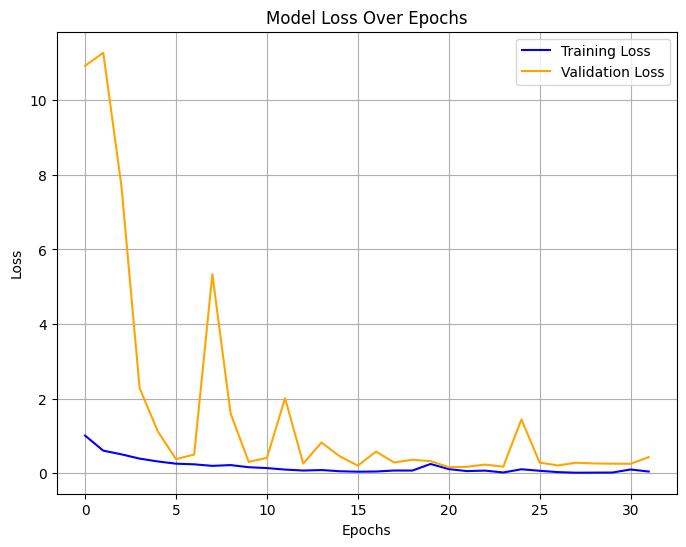

In [2]:
# Plot the training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
